In [1]:
import pandas as pd

df = pd.read_csv(
    "../datasets/final/deceptiscan_training.csv"
)

print(df.shape)

df.head()

(72877, 2)


,text,label
0,The product has many different sounds to choos...,1
1,"I absolutely love this device, I have replaced...",0
2,Durable and holds water until it has been filt...,1
3,"Works super well, as having dark hair I always...",1
4,Worked fine until it fell apart. The only prob...,1


In [2]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [3]:
df = df.dropna(
    subset=["text"]
)

In [4]:
df["word_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)

df["word_count"].describe()

count    72877.000000
mean        61.492693
std         63.936582
min          1.000000
25%         21.000000
50%         40.000000
75%         76.000000
max       2501.000000
Name: word_count, dtype: float64

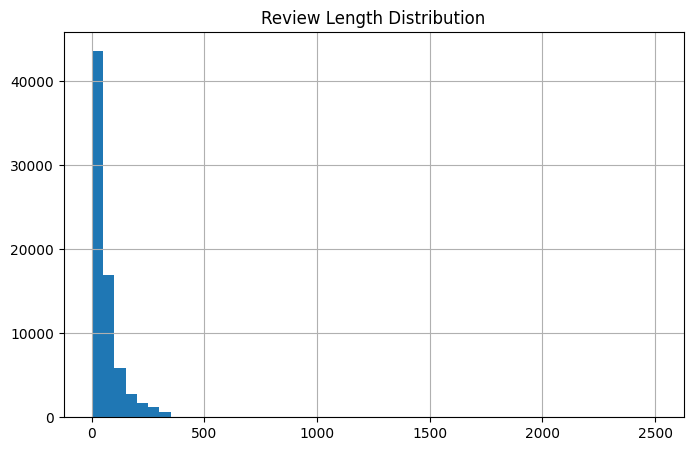

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["word_count"].hist(
    bins=50
)

plt.title(
    "Review Length Distribution"
)

plt.show()

In [6]:
import re

def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"www\S+",
        "",
        text
    )

    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [7]:
df["text"] = (
    df["text"]
    .apply(clean_text)
)

In [8]:
df = df[
    df["word_count"] >= 5
]

In [9]:
print(df.shape)

(71697, 3)


In [10]:
before = len(df)

df = df.drop_duplicates(
    subset=["text"]
)

after = len(df)

print(
    f"Removed {before-after} duplicates"
)

Removed 40 duplicates


In [11]:
print(
    df["label"]
    .value_counts()
)

print(
    df["label"]
    .value_counts(
        normalize=True
    )
)

label
1    42079
0    29578
Name: count, dtype: int64
label
1    0.587228
0    0.412772
Name: proportion, dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(train_df.shape)
print(test_df.shape)

(57325, 3)
(14332, 3)


In [ ]:
from pathlib import Path

Path(
    "../datasets/processed"
).mkdir(
    parents=True,
    exist_ok=True
)

In [13]:

train_df = train_df[
    ["text", "label"]
]

test_df = test_df[
    ["text", "label"]
]

In [14]:
print(train_df.columns)
print(test_df.columns)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


In [15]:
from pathlib import Path

Path(
    "../datasets/processed"
).mkdir(
    parents=True,
    exist_ok=True
)

In [16]:
train_df.to_csv(
    "../datasets/processed/train.csv",
    index=False
)

test_df.to_csv(
    "../datasets/processed/test.csv",
    index=False
)

print("Datasets saved")

Datasets saved


In [17]:
import pandas as pd

train_check = pd.read_csv(
    "../datasets/processed/train.csv"
)

test_check = pd.read_csv(
    "../datasets/processed/test.csv"
)

print(train_check.shape)
print(test_check.shape)

(57325, 2)
(14332, 2)


In [18]:
print(df.shape)

df.info()

df.head()

(71657, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 71657 entries, 0 to 72876
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        71657 non-null  object
 1   label       71657 non-null  int64 
 2   word_count  71657 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.2+ MB


,text,label,word_count
0,the product has many different sounds to choos...,1,63
1,i absolutely love this device i have replaced ...,0,53
2,durable and holds water until it has been filt...,1,19
3,works super well as having dark hair i always ...,1,53
4,worked fine until it fell apart the only probl...,1,28


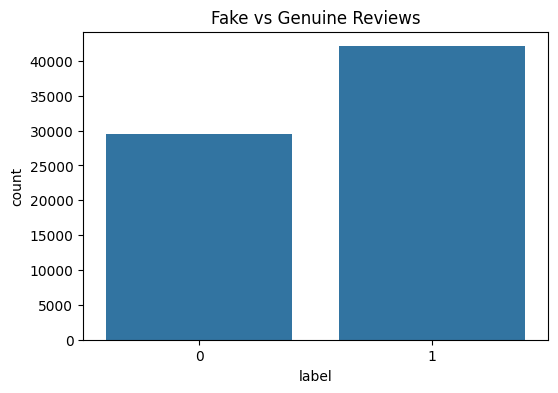

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=df
)

plt.title("Fake vs Genuine Reviews")
plt.show()

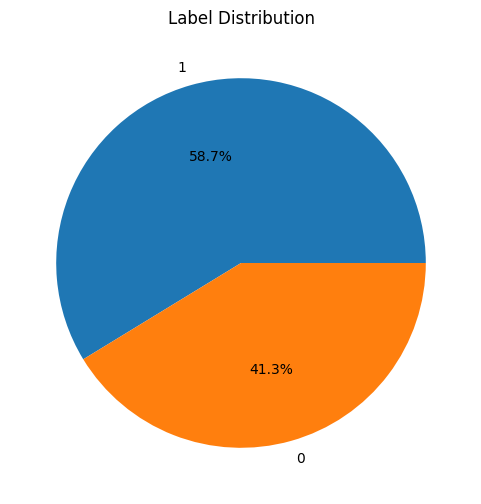

In [20]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Label Distribution")
plt.show()

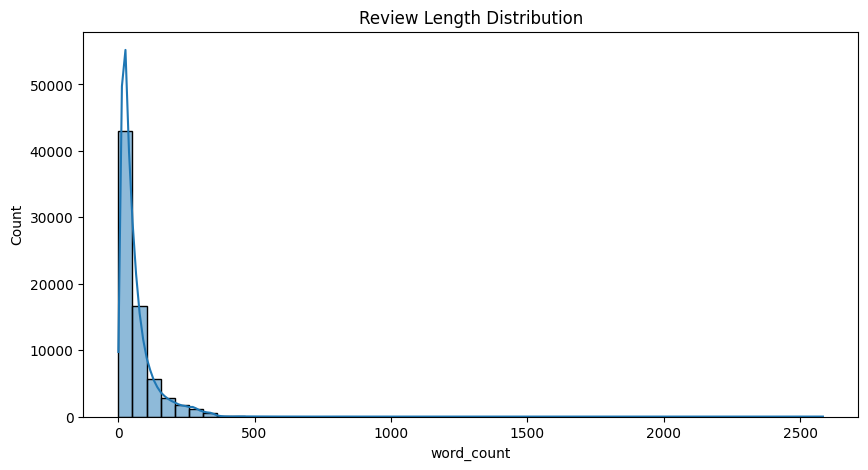

In [21]:
df["word_count"] = df["text"].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10,5))

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title("Review Length Distribution")
plt.show()

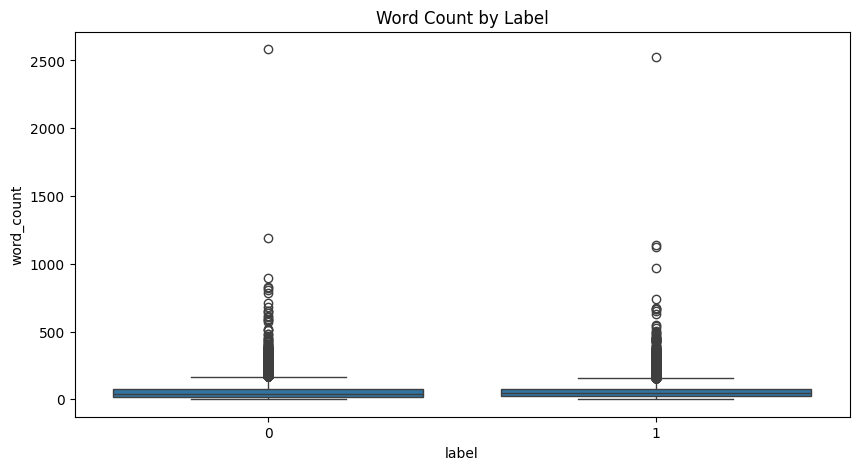

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="label",
    y="word_count",
    data=df
)

plt.title("Word Count by Label")
plt.show()

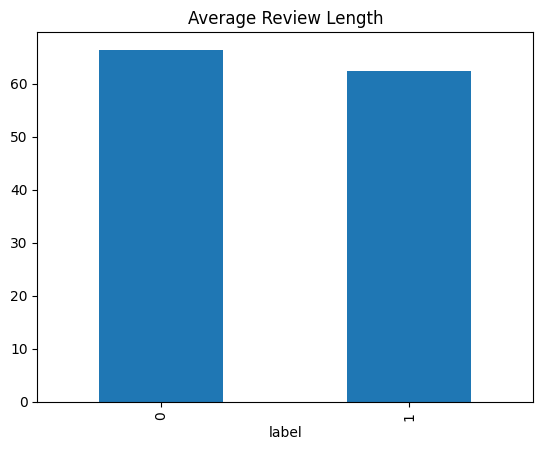

In [23]:
df.groupby("label")["word_count"].mean()

df.groupby("label")["word_count"].mean().plot(
    kind="bar"
)

plt.title("Average Review Length")
plt.show()

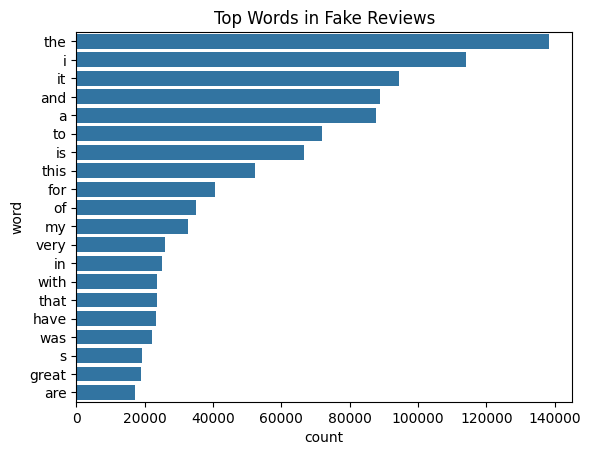

In [24]:
from collections import Counter

fake_text = " ".join(
    df[df["label"]==1]["text"]
)

words = fake_text.split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=["word","count"]
)

sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title("Top Words in Fake Reviews")
plt.show()

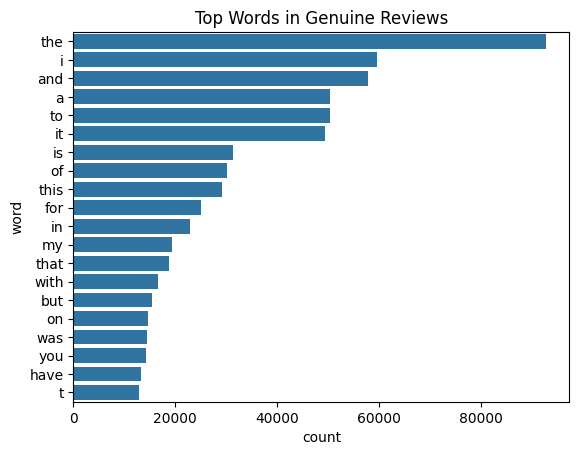

In [25]:
from collections import Counter

genuine_text = " ".join(
   df[df["label"]==0]["text"]
)

words = genuine_text.split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=["word","count"]
)

sns.barplot(
    x="count",
    y="word",
    data=common_df
)

plt.title("Top Words in Genuine Reviews")
plt.show()

In [1]:
from wordcloud import WordCloud

text = " ".join(df["text"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
)

wc.generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wc)
plt.axis("off")
plt.show()

NameError: name 'df' is not defined